<a href="https://colab.research.google.com/github/Santhosh261005/Deep-Learning/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

Original Image Shape: (300, 300, 1)


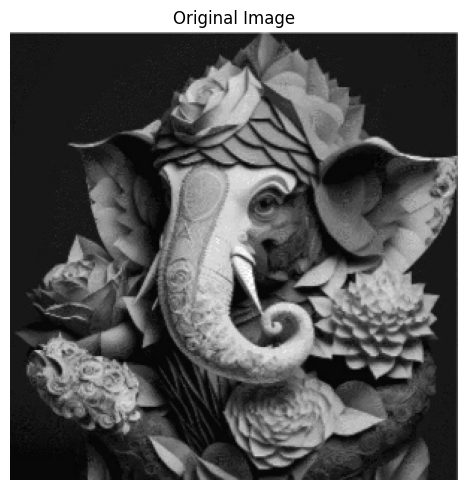

In [ ]:
image_path = "/content/ganesh.jpg"

image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, [300, 300])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

In [ ]:
image = tf.expand_dims(image, axis=0)

In [ ]:
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])

After Convolution Shape: (1, 300, 300, 1)


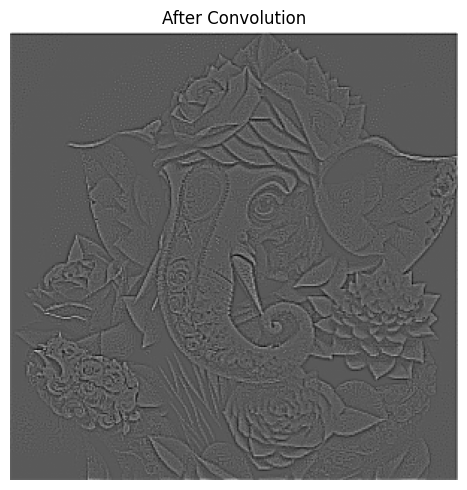

In [ ]:
conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=1,
    padding='SAME'
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()

After ReLU Shape: (1, 300, 300, 1)


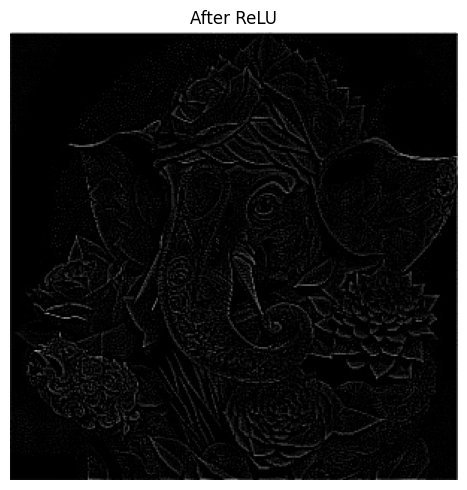

In [ ]:
relu_output = tf.nn.relu(conv_output)

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU")
plt.axis('off')
plt.show()


After Pooling Shape: (1, 150, 150, 1)


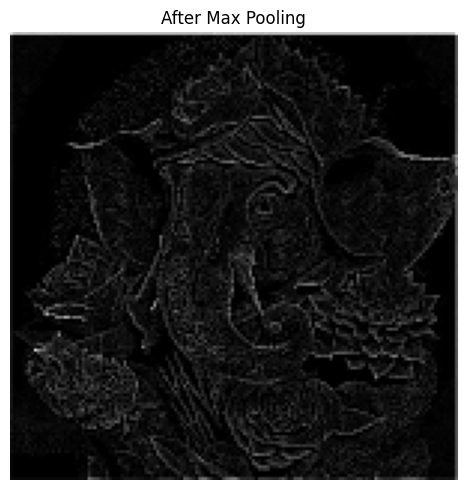

In [ ]:
pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=2,
    strides=2,
    padding='SAME'
)

print("After Pooling Shape:", pool_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Max Pooling")
plt.axis('off')
plt.show()

In [ ]:
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flatten Shape:", flatten_output.shape)

print("\nFirst 20 values of Flattened Vector:\n")
print(flatten_output.numpy()[0][:20])

After Flatten Shape: (1, 22500)

First 20 values of Flattened Vector:

[958.7936  797.3521  786.19244 794.52313 805.65356 804.58234 790.03644
 780.03906 793.3874  804.61115 803.9759  804.9922  800.68646 797.85443
 794.2366  787.8382  806.9244  780.4666  801.7538  789.82605]


In [ ]:
dense_layer = tf.keras.layers.Dense(
    units=64,
    activation='relu'
)

dense_output = dense_layer(flatten_output)

print("After Fully Connected Layer Shape:", dense_output.shape)


After Fully Connected Layer Shape: (1, 64)


Importing required libraries and MNIST dataset

In [3]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255


In [5]:
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

model = Sequential()
model.add(Conv2D(25, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(50, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_test, Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 89ms/step - accuracy: 0.9226 - loss: 0.2588 - val_accuracy: 0.9789 - val_loss: 0.0666
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9779 - loss: 0.0729 - val_accuracy: 0.9868 - val_loss: 0.0410
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.9837 - loss: 0.0535 - val_accuracy: 0.9890 - val_loss: 0.0334
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.9868 - loss: 0.0422 - val_accuracy: 0.9904 - val_loss: 0.0313
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.9894 - loss: 0.0354 - val_accuracy: 0.9880 - val_loss: 0.0341
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 87ms/step - accuracy: 0.9909 - loss: 0.0294 - val_accuracy: 0.9920 - val_loss: 0.0253
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9921 - loss: 0.0260 - val_accuracy: 0.9904 - val_loss: 0.0291
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.9930 - loss: 0.0228 - 

In [6]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0299
Test Accuracy: 0.9916


To make predictions using the trained model on the X_test dataset. This involves using the `predict` method and converting the probability outputs to class labels.



In [8]:
import numpy as np
y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

print("Shape of prediction probabilities:", y_pred_probs.shape)
print("Shape of predicted labels:", y_pred_labels.shape)
print("First 10 predicted probability vectors:\n", y_pred_probs[:10])
print("First 10 predicted labels:\n", y_pred_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Shape of prediction probabilities: (10000, 10)
Shape of predicted labels: (10000,)
First 10 predicted probability vectors:
 [[8.65949268e-09 4.96229234e-07 6.48474554e-07 3.35736217e-06
  8.69058780e-08 2.06042312e-08 6.10449052e-11 9.99992192e-01
  1.30422237e-07 3.07220671e-06]
 [7.76184334e-06 4.01731114e-07 9.99991357e-01 2.32918324e-10
  2.20167315e-08 9.49199486e-12 2.20535185e-07 1.28212407e-09
  2.78508622e-07 1.79369491e-10]
 [1.08226935e-07 9.99868631e-01 2.18881974e-06 2.94731861e-09
  1.03376951e-04 6.53607003e-07 2.15446607e-06 1.86234829e-05
  3.75912191e-06 5.33981222e-07]
 [9.99809265e-01 2.21027552e-08 1.03999599e-04 1.50509294e-09
  5.04621624e-08 1.78015421e-06 6.78395736e-05 4.77750245e-06
  3.86469128e-06 8.38617780e-06]
 [3.06983522e-10 1.79827631e-09 5.16637257e-08 1.22105481e-09
  9.99997318e-01 2.47389687e-09 4.31976268e-08 2.02589145e-08
  2.12914610e-08 2.43219915e-06]
 [4.05414333e-08 9.99938428e-01 7.18731997e-07 1.

Now we try to visualize some sample images from the X_test dataset along with their true and predicted labels to better understand the model's performance qualitatively. This involves selecting a few images, retrieving their true and predicted labels, and displaying them using matplotlib.



Displaying sample predictions:


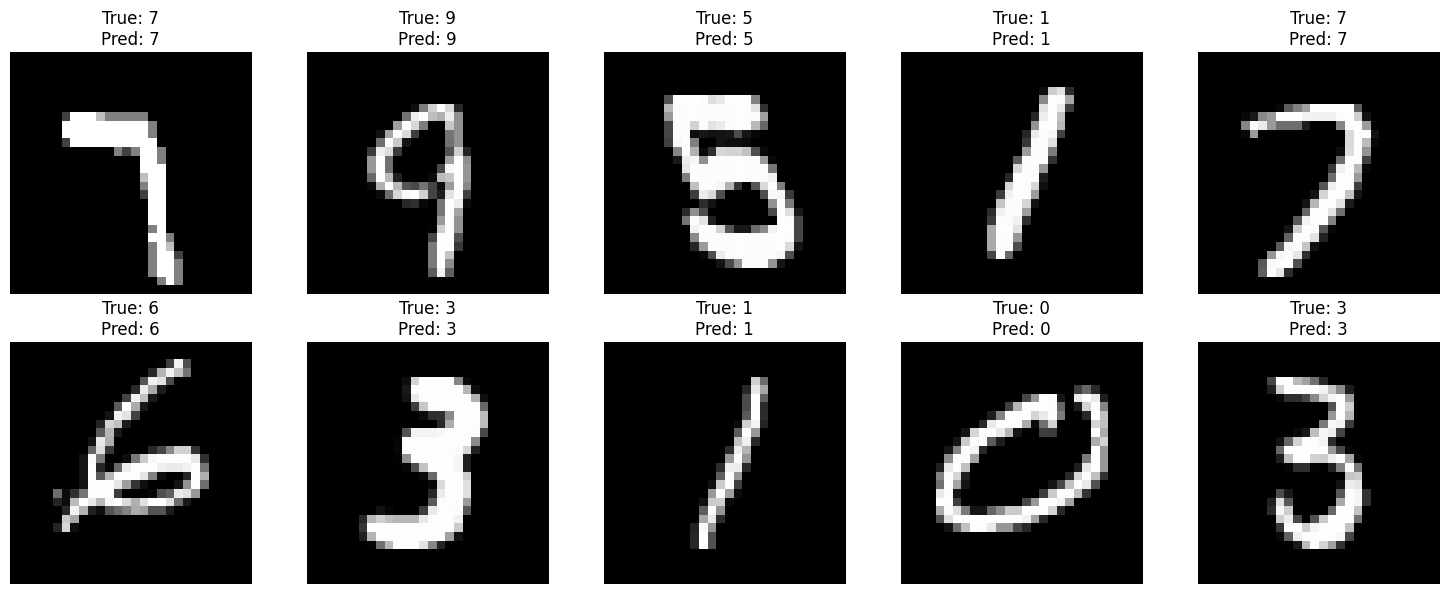

In [11]:
import matplotlib.pyplot as plt
import tensorflow as tf # Added tensorflow import

# Get true labels from Y_test (which is one-hot encoded)
y_true_labels = np.argmax(Y_test, axis=1)

def plot_predictions(images, true_labels, predicted_labels, num_samples=10):
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        # Choose random indices to display
        idx = np.random.randint(0, len(images))
        plt.subplot(2, num_samples // 2, i + 1) # Changed num_samples/2 to num_samples // 2
        plt.imshow(tf.squeeze(images[idx]), cmap='gray')
        plt.title(f"True: {true_labels[idx]}\nPred: {predicted_labels[idx]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Displaying sample predictions:")
plot_predictions(X_test, y_true_labels, y_pred_labels, num_samples=10)